In [13]:
import numpy as np
import json, h5py
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.io import fits
import astropy.units as u
from darksirenpop.utilities.utils import make_nice_plots, get_run
from darksirenpop.utilities.default_globals import *


def sigfig_str(x, sig=2):
    if x == 0:
        return "0"
    from decimal import Decimal
    d = Decimal(str(x))
    exponent = d.adjusted()  # position of most significant digit
    decimals = sig - 1 - exponent
    if decimals < 0:
        decimals = 0
    return f"{x:.{decimals}f}"


def run2color(run):
    if run == 'O1':
        color = 'blue'
        marker = 'X'
        zorder = 13
    elif run == 'O2':
        color = 'skyblue'
        marker = '^'
        zorder = 12
    elif run == 'O3':
        color = 'limegreen'
        marker = '*'
        zorder = 11
    elif run == 'O4':
        color = 'orangered'
        marker = '.'
        zorder = 10
    return color, marker, zorder


make_nice_plots()


In [14]:
QUAIA_PATH = '/home/lucas/Documents/PhD/agn_data/quaia_G20.5.fits'  # Original quaia data without redshift cut, for plotting!
PE_JSON_PATH = '/home/lucas/Documents/PhD/generated_data/gw/reweighted-gwtc5/real_PEsamples_reweight_gwtc5.json'  # Paths to reweighted GW samples to our PE prior and mass population

In [15]:
# Load Quaia

with fits.open(QUAIA_PATH) as hdul:
   hdul.verify('fix')
   quaia = hdul[1].data


In [16]:
# Load GW data

with open(PE_JSON_PATH, "r") as f:
    gw_path_dict = json.load(f)
gw_keys = list(gw_path_dict.keys())

redshift_dict = {}
redshift_list = []

log10_redshift_dict = {}
log10_redshift_list = []
for key in gw_keys:
    filename = gw_path_dict[key]
    
    with h5py.File(filename, 'r') as PEsamples:
        approx = list(PEsamples.keys())[0]
        data = PEsamples[approx]

        z = data['posterior_samples']['redshift']
        log10_z = np.log10(data['posterior_samples']['redshift'])

        redshift = np.median(z)
        redshift_lower = np.quantile(z, 0.16) - redshift
        redshift_upper = np.quantile(z, 0.84) - redshift
        del z

        log10_redshift = np.median(log10_z)
        log10_redshift_lower = np.quantile(log10_z, 0.16) - log10_redshift
        log10_redshift_upper = np.quantile(log10_z, 0.84) - log10_redshift
        del log10_z
    
    dat = np.array([redshift, redshift_upper, redshift_lower])
    redshift_dict[key] = dat
    redshift_list.append(redshift)
    print(key, 'redshift', redshift_dict[key])  
    
    log10_dat = np.array([log10_redshift, log10_redshift_upper, log10_redshift_lower])
    log10_redshift_dict[key] = log10_dat
    log10_redshift_list.append(log10_redshift)
    

GW190828_065509 redshift [ 0.30332496  0.07022725 -0.07327242]
GW190630_185205 redshift [ 0.16881091  0.06478128 -0.04220389]
GW170104_101158 redshift [ 0.21421091  0.04288833 -0.05324162]
GW190527_092055 redshift [ 0.48567704  0.16229023 -0.13959287]
GW190929_012149 redshift [ 0.77996313  0.26896506 -0.2395912 ]
GW190924_021846 redshift [ 0.10697894  0.02678741 -0.02863499]
GW190828_063405 redshift [ 0.38137609  0.06045655 -0.09202412]
GW151226_033853 redshift [ 0.0979378   0.02250241 -0.02526579]
GW190412_053044 redshift [ 0.14060033  0.01997767 -0.02073005]
GW170608_020116 redshift [ 0.07004321  0.01592621 -0.01517225]
GW190413_134308 redshift [ 0.8122935   0.14949486 -0.17499396]
GW190910_112807 redshift [ 0.37343737  0.08571708 -0.1041974 ]
GW190602_175927 redshift [ 0.5844352   0.1583005  -0.14210132]
GW190725_174728 redshift [ 0.19732512  0.05224629 -0.05009824]
GW190521_030229 redshift [ 0.78577555  0.1477408  -0.22123358]
GW190708_232457 redshift [ 0.19000719  0.03323261 -0.04

In [17]:
# Put GW quantiles in shape that works with plt.errorbar

z = np.array([log10_redshift_dict[k][0] for k in gw_keys])
zerr_lower = np.array( np.abs([redshift_dict[k][2] for k in gw_keys]) )
zerr_upper = np.array( [redshift_dict[k][1] for k in gw_keys] )
log10_zerr_lower = np.array( np.abs([log10_redshift_dict[k][2] for k in gw_keys]) )
log10_zerr_upper = np.array( [log10_redshift_dict[k][1] for k in gw_keys] )


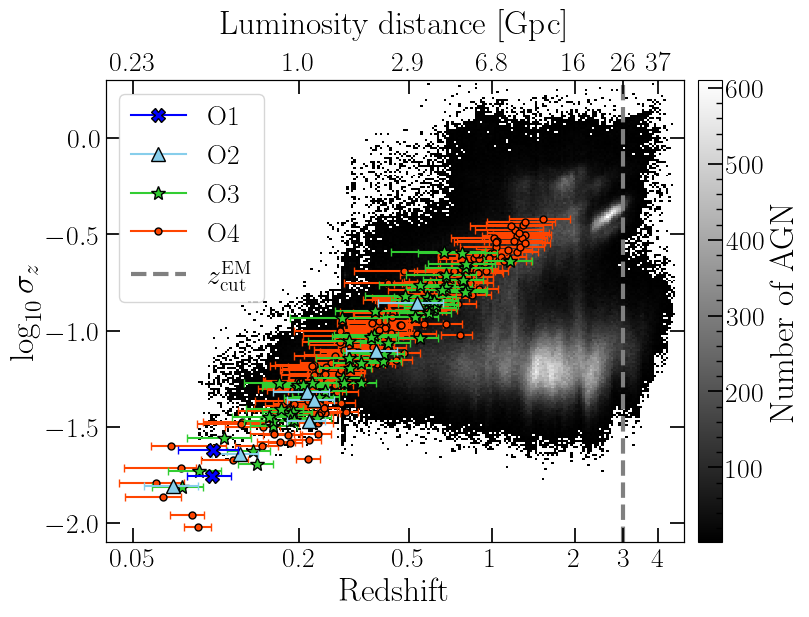

In [18]:
# Plotting

fig, ax = plt.subplots(figsize=(9,6))
for i, key in enumerate(gw_keys):
    run = get_run(key)
    color, marker, zorder = run2color(run)
    ax.errorbar(
        z[i],
        np.log10( (zerr_lower + zerr_upper)[i] / 2 ),
        xerr=[[log10_zerr_lower[i]], [log10_zerr_upper[i]]],
        marker=marker,
        zorder=zorder,
        markersize=10,
        markeredgecolor='black',
        capsize=3,
        color=color,
        alpha=1
    )
h = ax.hist2d(
                np.log10( quaia['redshift_quaia'] ),
                np.log10( quaia['redshift_quaia_err'] ),
                bins=200,
                cmin=1,
                cmap='grey',
                label='Quaia'
            )
h[3].set_rasterized(True)

cbar = fig.colorbar(h[3], ax=ax, pad=0.02)
cbar.set_label('Number of AGN')

ax.vlines(np.log10(3), -2.1, 0.3, label=r'$z_{\rm cut}^{\rm EM}$', linewidth=3, linestyles='dashed', color='gray', zorder=1)

# Top axis
upperax1 = ax.twiny()
upperticks = np.array([0.05, 0.2, 0.5, 1, 2, 3, 4])
upperax1.set_xlim(-1.4, np.log10(5))
upperax1.set_xticks(np.log10(upperticks))
dl_values = COSMO.luminosity_distance(upperticks).to(u.Gpc).value
labels = [sigfig_str(v, 2) for v in dl_values]
upperax1.set_xticklabels(labels)
upperax1.set_xlabel(r'Luminosity distance [Gpc]', labelpad=12, fontsize=24)
ax.set_xlim(-1.4, np.log10(5))
upperax1.set_xlim(-1.4, np.log10(5))
ax.set_ylim(-2.1, 0.3)
ax.set_xlabel('Redshift')
ax.set_ylabel(r'$\log_{10} \sigma_{z}$')

legend_handles = []
for run in ['O1', 'O2', 'O3', 'O4']:
    color, marker, _ = run2color(run)
    legend_handles.append(mpl.lines.Line2D([0], [0],
                                            marker=marker,
                                            linestyle='-',
                                            linewidth=1.5,
                                            color=color,
                                            markerfacecolor=color,
                                            markeredgecolor='black',
                                            markeredgewidth=1,
                                            markersize=10,
                                            label=run))
legend_handles.append(mpl.lines.Line2D([0], [0], linewidth=3, linestyle='dashed', label=r'$z_{\rm cut}^{\rm EM}$', color='gray'))
ax.legend(handles=legend_handles, loc='upper left')

ticks = upperticks
ax.minorticks_off()
upperax1.minorticks_off()
ax.set_xticks(np.log10(ticks))
ax.set_xticklabels([sigfig_str(v, 1) for v in upperticks])

# plt.savefig(f'{PLOT_DIR}/quaia_plus_gws.pdf', bbox_inches='tight')
plt.show()
